In [ ]:
from pathlib import Path
from typing import TypedDict
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

from rich.console import Console
from rich.pretty import Pretty
from rich.theme import Theme
from rich.panel import Panel


theme = Theme(
    {
        "json.key": "#c1a2ff",
        "json.string": "#FCCEA1",
        "json.number": "#A1C4FD",
        "json.boolean": "#A6F5D8",
        "json.null": "#ffb3ba",
    }
)

console = Console(
    theme=theme,
    force_terminal=True,
    force_jupyter=False,
    color_system="truecolor",
)


In [2]:
# get LLM
def get_model(model="gemini-2.5-flash", temperature=0.7, max_output_tokens=8000):
    model = ChatGoogleGenerativeAI(model=model, temperature=temperature, max_output_tokens=max_output_tokens)
    parser = StrOutputParser()

    chain = model | parser
    return chain


model = get_model()

In [3]:
# state
class BlogState(TypedDict):
    blog_topic: str
    blog_outline: str
    blog_content: str
    blog_summary: str

In [4]:
# topic generator
def generate_blog_topic(state: BlogState):
    prompt = ChatPromptTemplate(
        [
            (
                "system",
                "You are an astronomy research scout. Output exactly one high-interest trending astronomy topic as a single word or a strict compound noun. Do not include introductory text, punctuation, or formatting.",
            ),
            ("user", "Provide one trending astronomy topic."),
        ]
    )

    chain = prompt | model
    state["blog_topic"] = chain.invoke({})

    return state


In [5]:
# outline generator
def generate_blog_outline(state: BlogState) -> BlogState:
    prompt = ChatPromptTemplate(
        [
            (
                "system",
                "You are an expert technical editor. Generate a clear, structured Markdown outline for a deep-dive blog post based on the provided topic. Ensure a logical progression from introduction to technical breakdown and conclusion.",
            ),
            ("user", "Topic: {topic}"),
        ]
    )

    chain = prompt | model
    state["blog_outline"] = chain.invoke({"topic": state["blog_topic"]})
    return state


In [6]:
# blog generator
def generate_blog_content(state: BlogState) -> BlogState:
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are an authoritative science communicator. Expand the provided outline into a comprehensive, engaging, and scientifically accurate blog post. Use clear Markdown headers, bold text for key terms, and maintain an informative yet accessible tone.",
            ),
            ("user", "Topic: {topic}\n\nOutline:\n{outline}"),
        ]
    )

    chain = prompt | model
    state["blog_content"] = chain.invoke(
        {
            "topic": state["blog_topic"],
            "outline": state["blog_outline"],
        }
    )
    return state

In [7]:
# summary generator
def generate_blog_summary(state: BlogState) -> BlogState:
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are an executive editor. Create a dense, highly informative 3-4 sentence summary of the provided blog content. Capture the core thesis, primary scientific insights, and final conclusion without using fluff or introductory phrases.",
            ),
            ("user", "Content:\n{content}"),
        ]
    )

    chain = prompt | model
    state["blog_summary"] = chain.invoke({"content": state["blog_content"]})
    return state

In [8]:
# init graph
graph = StateGraph(BlogState)

In [9]:
# add nodes
graph.add_node("generate_blog_topic", generate_blog_topic)
graph.add_node("generate_blog_outline", generate_blog_outline)
graph.add_node("generate_blog_content", generate_blog_content)
graph.add_node("generate_blog_summary", generate_blog_summary)

In [10]:
# add edges
graph.add_edge(START, "generate_blog_topic")
graph.add_edge("generate_blog_topic", "generate_blog_outline")
graph.add_edge("generate_blog_outline", "generate_blog_content")
graph.add_edge("generate_blog_content", "generate_blog_summary")
graph.add_edge("generate_blog_summary", END)

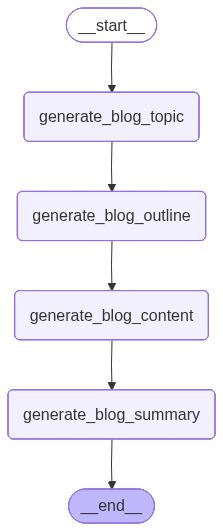

In [11]:
# compilation
workflow = graph.compile()
workflow

In [12]:
# execution
final_state = workflow.invoke({})

In [13]:
console.print(Pretty(final_state["blog_topic"], justify="center"))


                                  'Exoplanets'                                  


In [14]:
Path("files").mkdir(exist_ok=True)

with open("./files/1-outline.md", "w") as f:
    f.write(final_state["blog_outline"])

console.print(Markdown(final_state["blog_content"]))


              Exoplanets: Unveiling Worlds Beyond Our Solar System              

I. Introduction: A Universe of Other Worlds                                     

A. The Age-Old Question: For millennia, humanity has gazed at the night sky,    
wondering if we are alone. Are those twinkling lights merely distant suns, or do
they too host planets, perhaps even life? This profound curiosity, woven into   
the fabric of human thought, has driven poets, philosophers, and scientists     
alike.                                                                          

B. Defining Exoplanets: For most of history, this question remained firmly in   
the realm of speculation. But no longer. An exoplanet (or extrasolar planet) is 
simply defined as a planet that orbits a star other than our Sun. Their         
discovery, once a distant dream, has revolutionized our understanding of the    
universe, transforming our solar system from a unique cosmic anomaly into just  
one of countless planetar

In [15]:
with open("./files/2-blog_content.md", "w") as f:
    f.write(final_state["blog_content"])

console.print(Markdown(final_state["blog_content"]))


              Exoplanets: Unveiling Worlds Beyond Our Solar System              

I. Introduction: A Universe of Other Worlds                                     

A. The Age-Old Question: For millennia, humanity has gazed at the night sky,    
wondering if we are alone. Are those twinkling lights merely distant suns, or do
they too host planets, perhaps even life? This profound curiosity, woven into   
the fabric of human thought, has driven poets, philosophers, and scientists     
alike.                                                                          

B. Defining Exoplanets: For most of history, this question remained firmly in   
the realm of speculation. But no longer. An exoplanet (or extrasolar planet) is 
simply defined as a planet that orbits a star other than our Sun. Their         
discovery, once a distant dream, has revolutionized our understanding of the    
universe, transforming our solar system from a unique cosmic anomaly into just  
one of countless planetar

In [16]:
with open("./files/3-blog_summary.md", "w") as f:
    f.write(final_state["blog_summary"])

console.print(Markdown(final_state["blog_summary"]))


Exoplanet research has fundamentally reshaped our cosmic perspective, revealing 
thousands of diverse worlds—from "Hot Jupiters" to "Super-Earths"—are ubiquitous
rather than rare. Scientists detect these unseen planets using ingenious        
indirect methods like transit photometry and radial velocity, then characterize 
their mass, radius, density, and atmospheric composition, including potential   
biosignatures. This quest for habitability, focused on "Goldilocks Zones" and   
beyond, drives the development of next-generation telescopes like JWST and      
future missions. These discoveries profoundly suggest the high probability of   
life beyond Earth, redefining humanity's place in a crowded cosmos.             
